In [1]:
from world import World

world = World(100, 100)

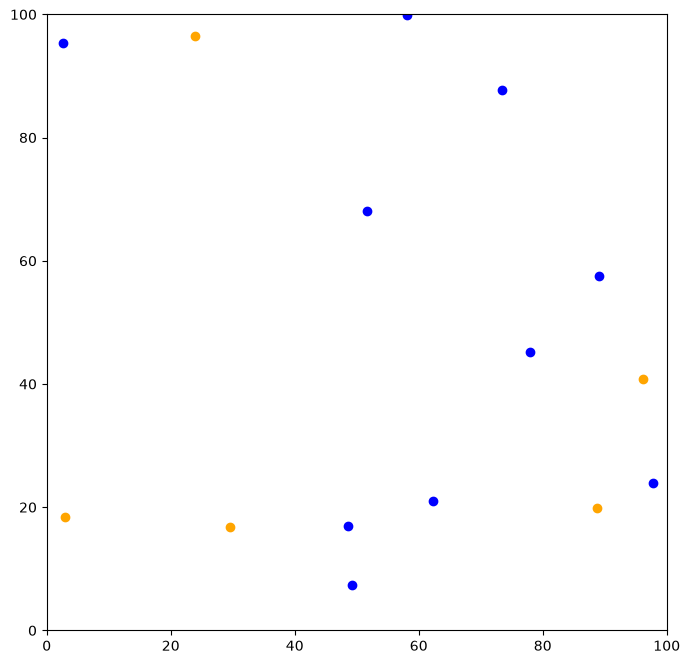

In [2]:
world.add_prey(number=10)
world.add_predator(number=5)

import matplotlib.pyplot as plt

# plot the world with the preys and predators
plt.figure(figsize=(8, 8))
plt.xlim(0, world.width)
plt.ylim(0, world.height)

for prey in world.preys:
    plt.scatter(prey.x, prey.y, c=world.color_prey)
for predator in world.predators:
    plt.scatter(predator.x, predator.y, c=world.color_predator)
plt.show()

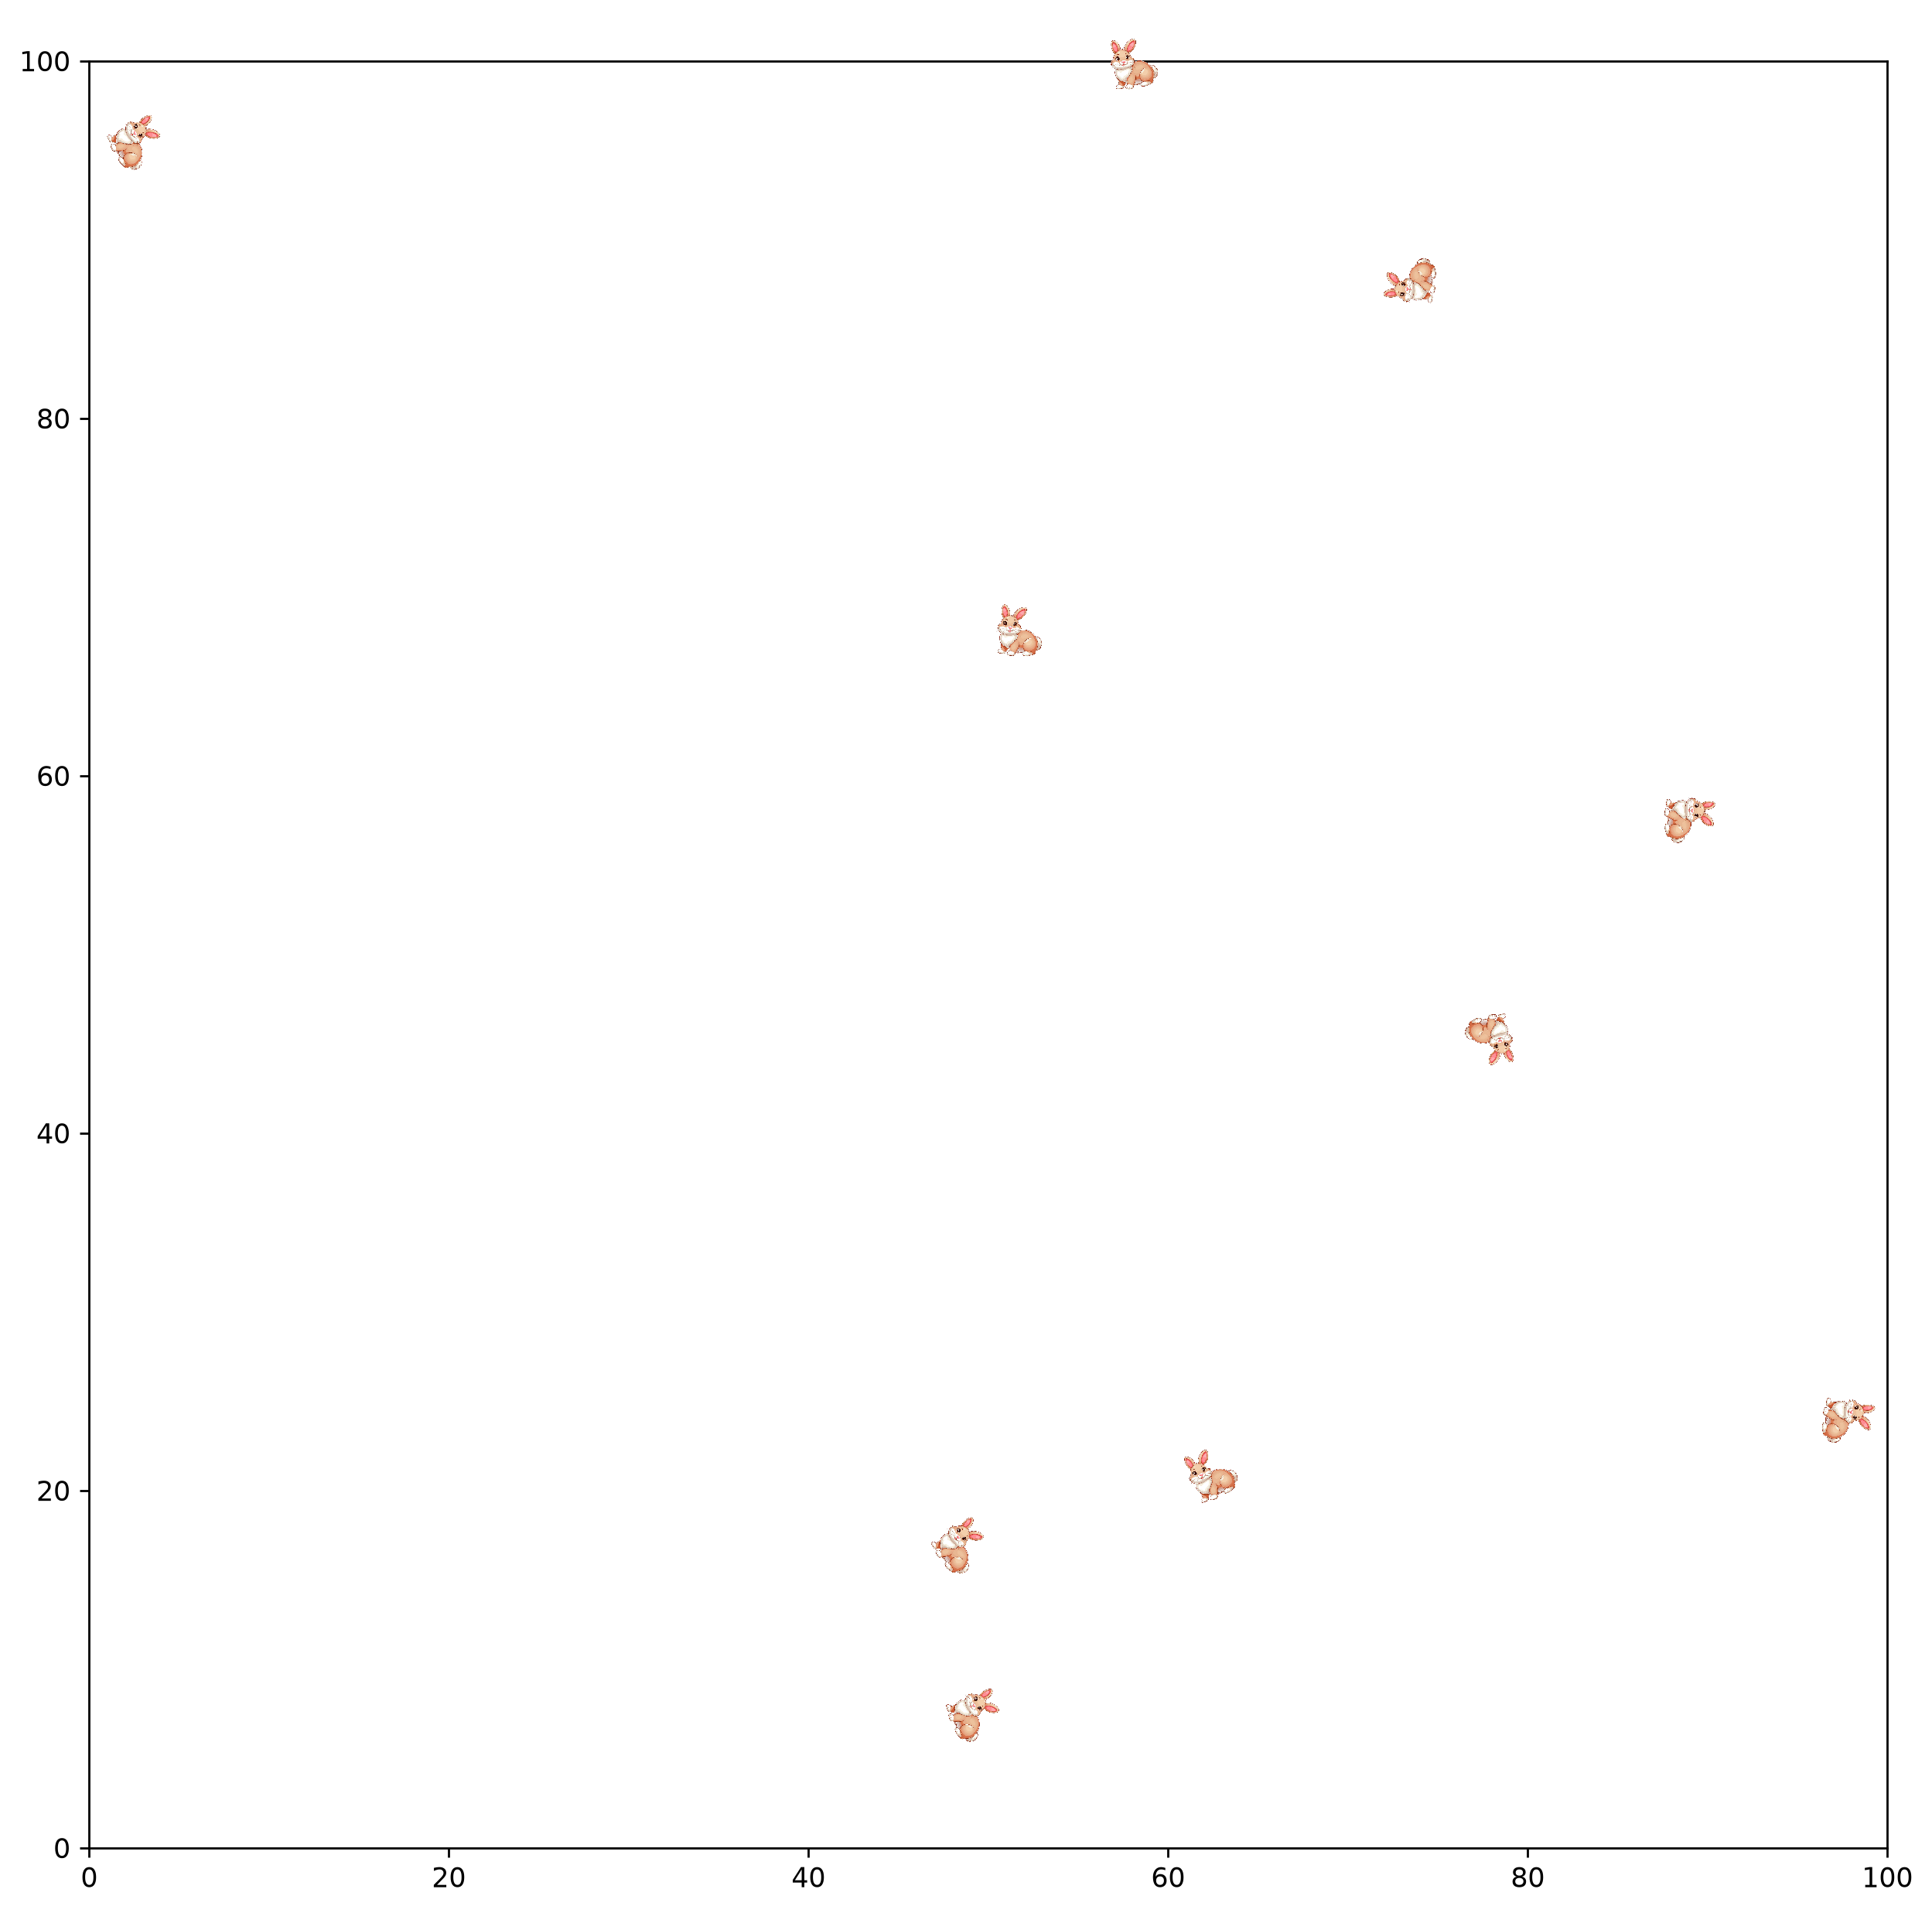

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np


# Loading the images with PIL
hare_img = Image.open("./images/hare.png")
fox_img = Image.open("./images/fox.png")


plt.figure(figsize=(12, 12), dpi=250)
plt.xlim(0, world.width)
plt.ylim(0, world.height)

ax = plt.gca()

for prey in world.preys:
    # Conversion in degree
    direction = prey.direction*180/np.pi  
    # Rotation of the image
    rotated_img = hare_img.rotate(
        -direction,
        resample=Image.Resampling.BICUBIC,
        expand=True
    )

    hare_icon = OffsetImage(
        np.array(rotated_img),
        zoom=0.05
    )

    ab = AnnotationBbox(
        hare_icon,
        (prey.x, prey.y),
        frameon=False
    )

    ax.add_artist(ab)


for predator in world.predators:

    direction = predator.direction*180/np.pi

    rotated_img = fox_img.rotate(
        -direction,
        resample=Image.Resampling.BICUBIC,
        expand=True
    )

    fox_icon = OffsetImage(
        np.array(rotated_img),
        zoom=0.05
    )

    ab = AnnotationBbox(
        fox_icon,
        (predator.x, predator.y),
        frameon=False
    )

    ax.add_artist(ab)

plt.show()

In [11]:
def time_course(world: World, N:int):

    hare_img = Image.open("./images/hare.png")
    fox_img = Image.open("./images/fox.png")

    for _ in range(N):

        # Update the world
        world.step()

        plt.figure(figsize=(12, 12), dpi=250)
        plt.xlim(0, world.width)
        plt.ylim(0, world.height)

        ax = plt.gca()

        for prey in world.preys:
            direction = prey.direction*180/np.pi
            rotated_img = hare_img.rotate(
                -direction,
                resample=Image.Resampling.BICUBIC,
                expand=True
            )

            hare_icon = OffsetImage(
                np.array(rotated_img),
                zoom=0.05
            )

            ab = AnnotationBbox(
                hare_icon,
                (prey.x, prey.y),
                frameon=False
            )

            ax.add_artist(ab)

        for predator in world.predators:
            direction = predator.direction*180/np.pi
            rotated_img = fox_img.rotate(
                -direction,
                resample=Image.Resampling.BICUBIC,
                expand=True
            )

            fox_icon = OffsetImage(
                np.array(rotated_img),
                zoom=0.05
            )

            ab = AnnotationBbox(
                fox_icon,
                (predator.x, predator.y),
                frameon=False
            )

            ax.add_artist(ab)

        plt.savefig(f"world_{_}.png")
        plt.close()
